<a href="https://colab.research.google.com/github/O-suke12/ObjectDetection/blob/main/BoundingBoxRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch.nn as nn
import torch
import pandas as pd
from PIL import Image
import os

# **Reference**

Dataset: https://www.kaggle.com/datasets/sshikamaru/car-object-detection

# **Datasets**

In [ ]:
! pip install kaggle
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [ ]:
! kaggle datasets download -d sshikamaru/car-object-detection

 95% 106M/112M [00:00<00:00, 217MB/s] 
100% 112M/112M [00:00<00:00, 188MB/s]


In [ ]:
! unzip  car-object-detection

Archive:  car-object-detection.zip
  inflating: data/sample_submission.csv  
  inflating: data/testing_images/vid_5_25100.jpg  
  inflating: data/testing_images/vid_5_25120.jpg  
  inflating: data/testing_images/vid_5_25140.jpg  
  inflating: data/testing_images/vid_5_25160.jpg  
  inflating: data/testing_images/vid_5_25180.jpg  
  inflating: data/testing_images/vid_5_25200.jpg  
  inflating: data/testing_images/vid_5_25220.jpg  
  inflating: data/testing_images/vid_5_25240.jpg  
  inflating: data/testing_images/vid_5_25260.jpg  
  inflating: data/testing_images/vid_5_26320.jpg  
  inflating: data/testing_images/vid_5_26400.jpg  
  inflating: data/testing_images/vid_5_26420.jpg  
  inflating: data/testing_images/vid_5_26560.jpg  
  inflating: data/testing_images/vid_5_26580.jpg  
  inflating: data/testing_images/vid_5_26600.jpg  
  inflating: data/testing_images/vid_5_26620.jpg  
  inflating: data/testing_images/vid_5_26640.jpg  
  inflating: data/testing_images/vid_5_26660.jpg  
  inf

In [ ]:
!ls /content/data/training_images

vid_4_10000.jpg  vid_4_16200.jpg  vid_4_21440.jpg  vid_4_30000.jpg
vid_4_1000.jpg	 vid_4_1620.jpg   vid_4_21460.jpg  vid_4_30020.jpg
vid_4_10020.jpg  vid_4_16220.jpg  vid_4_21480.jpg  vid_4_30440.jpg
vid_4_10040.jpg  vid_4_16240.jpg  vid_4_21500.jpg  vid_4_3120.jpg
vid_4_10060.jpg  vid_4_16260.jpg  vid_4_21520.jpg  vid_4_3140.jpg
vid_4_10080.jpg  vid_4_16280.jpg  vid_4_21540.jpg  vid_4_3160.jpg
vid_4_10100.jpg  vid_4_16300.jpg  vid_4_21560.jpg  vid_4_3180.jpg
vid_4_10120.jpg  vid_4_16320.jpg  vid_4_21580.jpg  vid_4_3200.jpg
vid_4_10140.jpg  vid_4_16400.jpg  vid_4_21600.jpg  vid_4_3220.jpg
vid_4_10160.jpg  vid_4_1640.jpg   vid_4_2160.jpg   vid_4_3240.jpg
vid_4_10180.jpg  vid_4_16420.jpg  vid_4_21620.jpg  vid_4_3260.jpg
vid_4_10200.jpg  vid_4_16440.jpg  vid_4_21640.jpg  vid_4_3280.jpg
vid_4_1020.jpg	 vid_4_16460.jpg  vid_4_21660.jpg  vid_4_3300.jpg
vid_4_10220.jpg  vid_4_16480.jpg  vid_4_21680.jpg  vid_4_3320.jpg
vid_4_10240.jpg  vid_4_16500.jpg  vid_4_21700.jpg  vid_4_3340.jpg
vid_4_102

<ipython-input-91-34b60c47fc20>:10: DeprecationWarning: an integer is required (got type numpy.float64).  Implicit conversion to integers using __int__ is deprecated, and may be removed in a future version of Python.
  bbox = torch.tensor(bbox, dtype=torch.int)


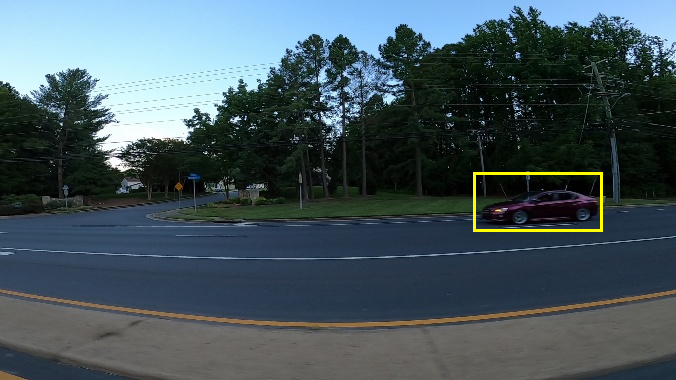

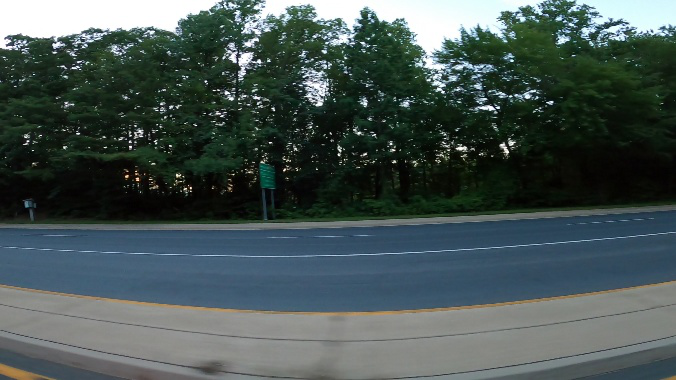

In [ ]:
import torchvision
from torchvision.io import read_image
from torchvision.utils import draw_bounding_boxes

select_row = 10
df_train = pd.read_csv("/content/data/train_solution_bounding_boxes (1).csv")
select = bbox = df_train.iloc[select_row,0]
img = read_image('/content/data/training_images/'+str(select))
bbox = df_train.iloc[select_row,1:5]
bbox = torch.tensor(bbox, dtype=torch.int)
bbox=bbox.unsqueeze(0)
img=draw_bounding_boxes(img, bbox, width=3, colors=(255,255,0))
img = torchvision.transforms.ToPILImage()(img)
img.show()
train_data[select_row][0].show()

In [ ]:
print(img.size)

(676, 380)


In [ ]:
df_train.head()

,image,xmin,ymin,xmax,ymax
0,vid_4_1000.jpg,281.259045,187.035071,327.727931,223.225547
1,vid_4_10000.jpg,15.163531,187.035071,120.329957,236.430180
2,vid_4_10040.jpg,239.192475,176.764801,361.968162,236.430180
3,vid_4_10020.jpg,496.483358,172.363256,630.020260,231.539575
4,vid_4_10060.jpg,16.630970,186.546010,132.558611,238.386422


In [ ]:
len(train_data)
len(df_train)

559

In [ ]:
!ls /content/data

 sample_submission.csv	 training
 testing		'train_solution_bounding_boxes (1).csv'


In [ ]:
transform = transforms.Compose([
  # transforms.PILToTensor(),
])

train_data = torchvision.datasets.ImageFolder("/content/data/", transform = transform)

def data_generator(df, batch_size=16):
  while True:
    for i in range(batch_size):
      index = np.random.randint(0, len(df_train))
      row = df_train[index, :]
      

FileNotFoundError: ignored

# **Model**

In [ ]:
class car_detection(nn.Module):
  def __init__(self)->None:
    super().__init__()
    self.block = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
        nn.MaxPool2d(2,2),
        nn.ReLU(),
        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
        nn.MaxPool2d(2,2),
        nn.ReLU(),
        nn.Conv2d(in_channels=32, out_channels=1, kernel_size=3, padding=1),
        nn.MaxPool2d(2,2),
        nn.ReLU(),
    )
    self.fully_connective_layer = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=47*84, out_features=1024),
        nn.ReLU(),
        nn.Linear(in_features=1024, out_features=128),
        nn.ReLU(),
        nn.Linear(in_features=128, out_features=32),
         nn.ReLU(),
        nn.Linear(in_features=32, out_features=4),
    )
  def forward(self, X):
    X = self.block(X)
    X = self.fully_connective_layer(X)
    return X

model = car_detection()


In [ ]:
import torch
from PIL import Image
import torchvision.transforms as transforms
  

df_train = pd.read_csv("/content/data/train_solution_bounding_boxes (1).csv")
select = df_train.iloc[select_row,0]
image = Image.open('/content/data/training_images/'+str(select))

transform = transforms.Compose([
    transforms.PILToTensor()
])
  
img_tensor = transform(image).to(torch.float32)
sampel_pred = model(img_tensor)

# **Loss fucntion**

IoU

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# return IOU= area of intersection / area of union
def IoU (box_preds, box_labels):
  box1_left = box_preds[...,0:1]
  box1_up = box_preds[...,1:2]
  box1_right = box_preds[...,2:3]
  box1_low = box_preds[...,3:4]
  box2_left = box_labels[...,0:1]
  box2_up = box_labels[...,1:2]
  box2_right = box_labels[...,2:3]
  box2_low = box_labels[...,3:4]

  box_right = torch.min(box1_right, box2_right)
  box_left = torch.max(box1_left, box2_left)
  box_low = torch.min(box1_low, box2_low)
  box_up = torch.max(box1_up, box2_up)
  intersection_area = (box_right-box_left).clamp(0)*(box_low-box_up).clamp(0)
  union_area = abs((box1_right-box1_left)*(box1_low-box1_up))+abs((box2_right-box2_left)*(box2_low-box2_up))-intersection_area+1e-6
  return intersection_area/union_area

In [ ]:
IoU(sampel_pred.squeeze(0), bbox.squeeze(0))

tensor([0.], grad_fn=<DivBackward0>)

In [ ]:
loss_fn = nn.MSELoss()

# **Training and Evaluation**

(tensor([[[183, 184, 184,  ..., 132, 133, 132],
          [184, 185, 185,  ..., 134, 134, 133],
          [186, 186, 186,  ..., 134, 134, 137],
          ...,
          [ 91,  93,  94,  ...,  98,  98,  98],
          [ 45,  42,  50,  ..., 100,  99,  99],
          [ 41,  40,  43,  ...,  95,  93,  92]],
 
         [[216, 217, 217,  ..., 184, 185, 184],
          [217, 218, 218,  ..., 184, 184, 183],
          [219, 219, 219,  ..., 184, 184, 187],
          ...,
          [ 79,  81,  80,  ...,  72,  72,  72],
          [ 44,  41,  46,  ...,  75,  74,  74],
          [ 43,  40,  41,  ...,  71,  69,  68]],
 
         [[251, 252, 252,  ..., 234, 235, 234],
          [252, 253, 253,  ..., 235, 235, 234],
          [254, 254, 254,  ..., 235, 235, 238],
          ...,
          [ 55,  55,  54,  ...,  39,  39,  39],
          [ 40,  36,  35,  ...,  45,  44,  44],
          [ 56,  50,  46,  ...,  43,  41,  40]]], dtype=torch.uint8), 0)

AttributeError: ignored

In [ ]:
epochs = 10

for epoch in epochs:
  for batch in train_data:
  batch = batch.to(tensor.float)
  
  model.train()

  y_pred =  torch.tensor(model(image)).squeeze(0)
  loss = loss_fn(y_pred,)

IndentationError: ignored